## Importações

In [27]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TCNModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.timeseries_generation import datetime_attribute_timeseries


warnings.filterwarnings("ignore")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

## Carregamento de dados

In [28]:
dataframe_n_ne = pd.read_csv("INTERCAMBIO_NORTE_NORDESTE_2024-2025.csv", sep=";", encoding="utf-8")

dataframe_n_ne["din_instante"] = pd.to_datetime(dataframe_n_ne["din_instante"])

dataframe_n_ne.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16080 entries, 0 to 16079
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   din_instante            16080 non-null  datetime64[ns]
 1   nom_subsistema_origem   16080 non-null  object        
 2   nom_subsistema_destino  16080 non-null  object        
 3   val_intercambiomwmed    16080 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 502.6+ KB


## Carrega dataset

In [29]:
# Define dataset
range_train_val = pd.date_range(start="2024-01-01 00:00:00", end="2025-09-30 23:59:00", freq="h")
range_compare = pd.date_range(start="2025-10-01 00:00:00", end="2025-10-07 23:59:00", freq="h")

dataframe_n_ne_set2025 = dataframe_n_ne[dataframe_n_ne['din_instante'].isin(range_train_val)]
dataframe_n_ne_compare = dataframe_n_ne[dataframe_n_ne['din_instante'].isin(range_compare)]

In [30]:
# Criar TimeSeries
ts = TimeSeries.from_dataframe(dataframe_n_ne_set2025, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="h")

# Create training and validation sets:
train, val = ts.split_after(pd.Timestamp("2025-04-30 23:59:00"))

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

In [31]:
# Adicionar a covariável dia do mês (scaling not required as one-hot-encoded)
weekday_series = datetime_attribute_timeseries(
    scaler.transform(TimeSeries.from_dataframe(dataframe_n_ne, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="h")),
    attribute="weekday",
    one_hot=True
)

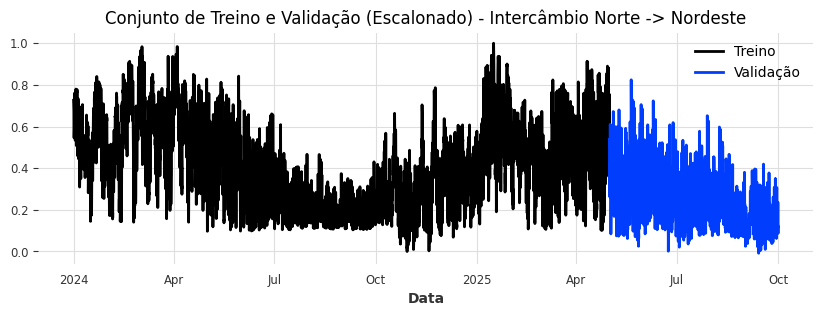

In [32]:
plt.figure(figsize=(10, 3))
train_scaled.plot(label="Treino")
val_scaled.plot(label="Validação")
plt.title('Conjunto de Treino e Validação (Escalonado) - Intercâmbio Norte -> Nordeste')
plt.xlabel('Data')
plt.legend()

## Construir modelo

In [33]:
model_name = "TCN_Intercambio_N_NE_Horario_2024_2025"
my_model = TCNModel(
    input_chunk_length=168, # 1 semana
    output_chunk_length=24,  # 1 dia
    n_epochs=20,
    dropout=0.2,
    dilation_base=2,
    weight_norm=True,
    kernel_size=7,
    num_filters=24,
    nr_epochs_val_period=1,
    random_state=0,
    save_checkpoints=True,
    model_name=model_name,
    force_reset=True,
    **generate_torch_kwargs(),
)

## Treinar Modelo

In [34]:
my_model.fit(
    series=train_scaled,
    past_covariates=weekday_series,
    val_series=val_scaled,
    val_past_covariates=weekday_series,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 26.3 K | train
-------------------------------------------------------------
26.3 K    Trainable params
0         Non-trainable params
26.3 K    Total params
0.105     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


TCNModel(output_chunk_shift=0, kernel_size=7, num_filters=24, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.2, input_chunk_length=168, output_chunk_length=24, n_epochs=20, nr_epochs_val_period=1, random_state=0, save_checkpoints=True, model_name=TCN_Intercambio_N_NE_Horario_2024_2025, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu', 'callbacks': [<darts.utils.callbacks.TFMProgressBar object at 0x000001F2E68DA550>]})

## Carregar Modelo

In [35]:
my_model = TCNModel.load_from_checkpoint(model_name=model_name, best=True)

## Backtest

In [36]:
backtest = my_model.historical_forecasts(
    series=ts_scaled,
    past_covariates=weekday_series,
    start=val_scaled.start_time(),
    forecast_horizon=168, # 4 semanas
    stride=168, # 4 semanas
    last_points_only=False,
    retrain=False,
    verbose=True,
)
backtest = concatenate(backtest)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Generating TimeSeries:   0%|          | 0/21 [00:00<?, ?it/s]

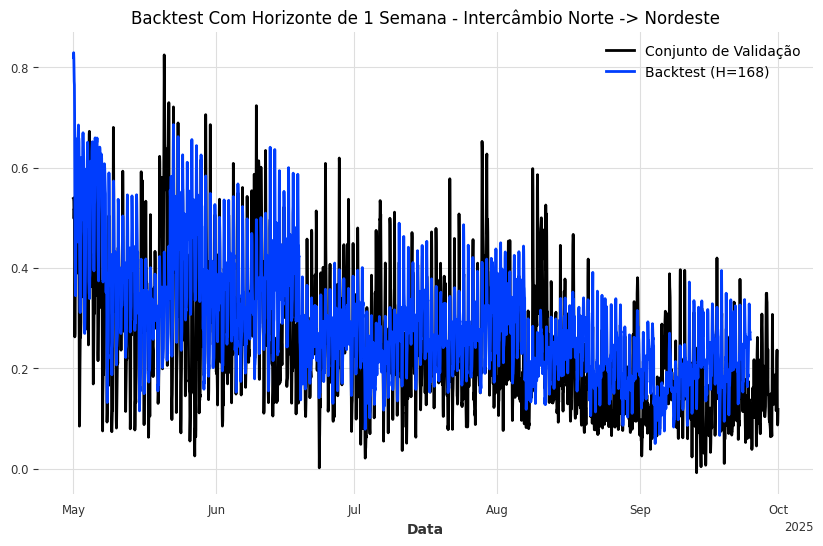

In [37]:
plt.figure(figsize=(10, 6))
val_scaled.plot(label="Conjunto de Validação")
backtest.plot(label="Backtest (H=168)")
plt.title('Backtest Com Horizonte de 1 Semana - Intercâmbio Norte -> Nordeste')
plt.xlabel('Data')
plt.legend()

In [38]:
from darts.metrics import mae, mse

print(f"MAE: {mae(val_scaled,backtest)}")
print(f"MSE: {mse(val_scaled,backtest)}")

MAE: 0.09278965458131586
MSE: 0.013672261713428252


In [39]:
# dados de outubro
real = TimeSeries.from_dataframe(dataframe_n_ne_compare, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="h")

# Previsão para o próximo mês (outubro de 2025)
pred_scaled = my_model.predict(
    n=168,
    series=ts,               # A partir de onde prever (fim do treino+validação)
    past_covariates=weekday_series # Covariáveis disponíveis (precisa conter os valores para o horizonte de previsão)
)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


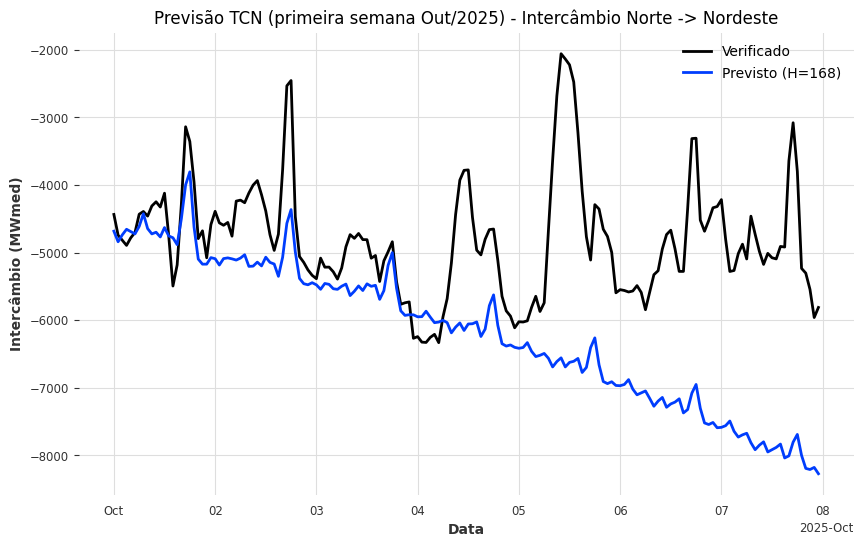

In [40]:
predicted = pred_scaled

plt.figure(figsize=(10, 6))
real.plot(label="Verificado")
pred_scaled.plot(label="Previsto (H=168)")
plt.title('Previsão TCN (primeira semana Out/2025) - Intercâmbio Norte -> Nordeste')
plt.ylabel('Intercâmbio (MWmed)')
plt.xlabel('Data')
plt.legend()

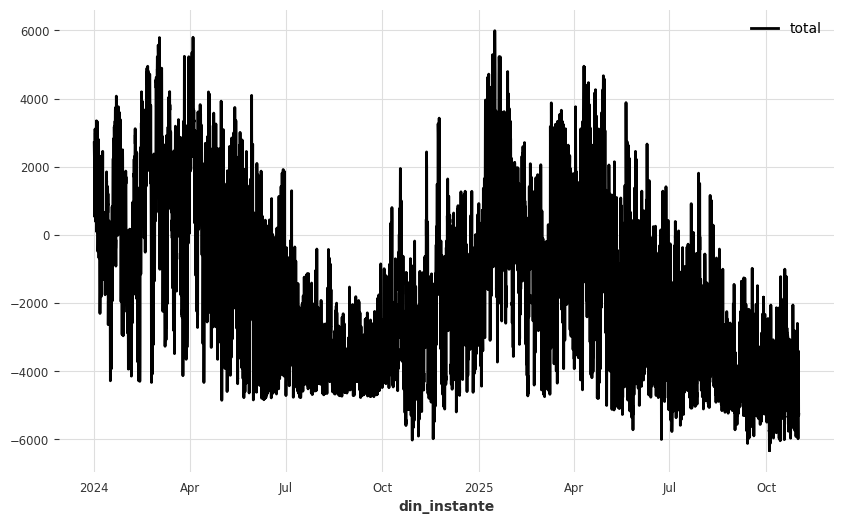

In [42]:
total = TimeSeries.from_dataframe(dataframe_n_ne, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="h")

plt.figure(figsize=(10, 6))
total.plot(label="total")
plt.legend()